# QTQ Measurement v2 — outlier-aware magnitude quantizers

Follow-up to `measurement.ipynb`. v1 found that the TFIM ground state compressed *worse* than Haar under the full pipeline because Lloyd-Max under-resolves the heavy-tailed post-WHT magnitude distribution (top coefficient at 0.682 vs median 5.3e-4 → 66% relative error on the largest coefficient). This notebook tests three outlier-aware quantizers as drop-in replacements for stage 2:

- **top-k** — k largest |c| stored exact, rest Lloyd-Max'd
- **log** — Lloyd-Max in log space
- **percentile** — 99th-percentile outliers stored exact, bulk-only Lloyd-Max

Plus the original **lloyd** as the comparison baseline. Full pipeline only (WHT + mag quant + phase quant + QJL). 3 states × 4 quantizers × 3 bit budgets × 20 samples = 720 measurements, plus a top-k k-sweep at 3/3 over k ∈ {4, 8, 16, 32} for 3 states × 4 ks × 20 samples = 240. Total: 960.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

STATE_NAMES = ['haar', 'tfim', 'mps']
QUANTIZERS = ['lloyd', 'topk', 'log', 'percentile']
BIT_BUDGETS = [(2, 2), (3, 3), (4, 4)]
K_SWEEP = [4, 8, 16, 32]
N_SAMPLES = 20

STATE_LABELS = {'haar': 'Haar-random', 'tfim': 'TFIM ground state', 'mps': 'Random MPS (χ=16)'}
QUANTIZER_LABELS = {
    'lloyd': 'Lloyd-Max (baseline)',
    'topk': 'Top-k exact + Lloyd-Max',
    'log': 'Log-domain Lloyd-Max',
    'percentile': 'Percentile-clip + Lloyd-Max',
}
QUANTIZER_COLORS = {'lloyd': 'C0', 'topk': 'C1', 'log': 'C2', 'percentile': 'C3'}
QUANTIZER_MARKERS = {'lloyd': 'o', 'topk': 's', 'log': '^', 'percentile': 'D'}

print('imports ok; numpy', np.__version__)

imports ok; numpy 2.4.4


In [2]:
# Main grid: every (state, quantizer, bit_budget, sample). Top-k uses default k=8.
records = []
t0 = time.time()
for state_name in STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    state_t0 = time.time()
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        for bits_mag, bits_phase in BIT_BUDGETS:
            for q in QUANTIZERS:
                qjl_seed = 10_000 * (1 + STATE_NAMES.index(state_name)) + sample_idx
                payload = pl.compress(
                    psi, 'full',
                    bits_mag=bits_mag, bits_phase=bits_phase,
                    mag_quantizer=q,
                    qjl_seed=qjl_seed,
                )
                psi_hat = pl.decompress(payload)
                records.append({
                    'state_class': state_name,
                    'magnitude_quantizer': q,
                    'bits_per_magnitude': bits_mag,
                    'bits_per_phase': bits_phase,
                    'k': 8 if q == 'topk' else None,
                    'sample_idx': sample_idx,
                    'fidelity': pl.fidelity(psi, psi_hat),
                    'compression_ratio': pl.compression_ratio(payload),
                })
    print(f'main grid {state_name:>5}: {time.time() - state_t0:6.1f}s')

main_t = time.time() - t0
print(f'main grid done: {len(records)} rows, {main_t:.1f}s')

main grid  haar:   17.9s


main grid  tfim:   17.8s


main grid   mps:   17.9s
main grid done: 720 rows, 53.5s


In [3]:
# Top-k k-sweep at 3/3 default budget. k=8 already in main grid; re-run all
# four k values here for clean per-cell statistics.
ks_t0 = time.time()
for state_name in STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        for k in K_SWEEP:
            qjl_seed = 20_000 * (1 + STATE_NAMES.index(state_name)) + sample_idx
            payload = pl.compress(
                psi, 'full',
                bits_mag=3, bits_phase=3,
                mag_quantizer='topk', topk=k,
                qjl_seed=qjl_seed,
            )
            psi_hat = pl.decompress(payload)
            records.append({
                'state_class': state_name,
                'magnitude_quantizer': 'topk_sweep',
                'bits_per_magnitude': 3,
                'bits_per_phase': 3,
                'k': k,
                'sample_idx': sample_idx,
                'fidelity': pl.fidelity(psi, psi_hat),
                'compression_ratio': pl.compression_ratio(payload),
            })

df = pd.DataFrame(records)
df.to_csv('results_v2.csv', index=False)
print(f'k-sweep done: +{len(df) - 720} rows, {time.time() - ks_t0:.1f}s')
print(f'\nTotal: {len(df)} rows written to results_v2.csv')
df.head()

k-sweep done: +240 rows, 18.0s

Total: 960 rows written to results_v2.csv


,state_class,magnitude_quantizer,bits_per_magnitude,bits_per_phase,k,sample_idx,fidelity,compression_ratio
0,haar,lloyd,2,2,NaN,0,0.840932,12.337349
1,haar,topk,2,2,8.0,0,0.841278,11.636364
2,haar,log,2,2,NaN,0,0.832175,12.337349
3,haar,percentile,2,2,NaN,0,0.840980,11.361997
4,haar,lloyd,3,3,NaN,0,0.957676,8.752137


In [4]:
# Mean fidelity per (state, quantizer, bit budget). Excludes the topk_sweep rows.
main = df[df['magnitude_quantizer'] != 'topk_sweep'].copy()
agg = (main.groupby(['state_class', 'magnitude_quantizer', 'bits_per_magnitude'])
             .agg(fid_mean=('fidelity', 'mean'),
                  fid_std=('fidelity', 'std'),
                  ratio=('compression_ratio', 'mean'))
             .reset_index())
agg['cell'] = agg.apply(lambda r: f"{r['fid_mean']:.4f} ± {r['fid_std']:.4f}  ({r['ratio']:.2f}x)", axis=1)
summary = agg.pivot_table(
    index=['state_class', 'magnitude_quantizer'],
    columns='bits_per_magnitude',
    values='cell',
    aggfunc='first',
).reindex([(s, q) for s in STATE_NAMES for q in QUANTIZERS])
summary.columns = [f'{c}b mag/phase' for c in summary.columns]
print('Mean fidelity ± std (compression ratio) — n=20 per cell, full pipeline:')
print(summary.to_string())

Mean fidelity ± std (compression ratio) — n=20 per cell, full pipeline:
                                              2b mag/phase              3b mag/phase              4b mag/phase
state_class magnitude_quantizer                                                                               
haar        lloyd                0.8425 ± 0.0060  (12.34x)  0.9572 ± 0.0013  (8.75x)  0.9889 ± 0.0005  (6.69x)
            topk                 0.8447 ± 0.0062  (11.64x)  0.9582 ± 0.0015  (8.40x)  0.9892 ± 0.0004  (6.49x)
            log                  0.8333 ± 0.0059  (12.34x)  0.9552 ± 0.0017  (8.75x)  0.9885 ± 0.0005  (6.69x)
            percentile           0.8451 ± 0.0065  (11.36x)  0.9583 ± 0.0013  (8.26x)  0.9893 ± 0.0004  (6.41x)
tfim        lloyd                0.7875 ± 0.0158  (12.34x)  0.8042 ± 0.0073  (8.75x)  0.8103 ± 0.0027  (6.69x)
            topk                 0.9604 ± 0.0036  (11.64x)  0.9890 ± 0.0010  (8.40x)  0.9897 ± 0.0007  (6.49x)
            log                  0.4201 

In [5]:
# K-sweep summary at 3/3.
ks = df[df['magnitude_quantizer'] == 'topk_sweep'].copy()
ks_agg = (ks.groupby(['state_class', 'k'])
             .agg(fid_mean=('fidelity', 'mean'),
                  fid_std=('fidelity', 'std'),
                  ratio=('compression_ratio', 'mean'))
             .reset_index())
print('Top-k k-sweep at 3/3 (n=20 per cell):')
for s in STATE_NAMES:
    print(f'\n  {s}:')
    sub = ks_agg[ks_agg['state_class'] == s]
    for _, r in sub.iterrows():
        print(f'    k={int(r["k"]):>2}  F={r["fid_mean"]:.4f} ± {r["fid_std"]:.4f}  ratio={r["ratio"]:.2f}x')

Top-k k-sweep at 3/3 (n=20 per cell):

  haar:
    k= 4  F=0.9579 ± 0.0017  ratio=8.57x
    k= 8  F=0.9582 ± 0.0017  ratio=8.40x
    k=16  F=0.9585 ± 0.0017  ratio=8.08x
    k=32  F=0.9589 ± 0.0017  ratio=7.50x

  tfim:
    k= 4  F=0.9783 ± 0.0018  ratio=8.57x
    k= 8  F=0.9890 ± 0.0010  ratio=8.40x
    k=16  F=0.9953 ± 0.0004  ratio=8.08x
    k=32  F=0.9986 ± 0.0001  ratio=7.50x

  mps:
    k= 4  F=0.9562 ± 0.0018  ratio=8.57x
    k= 8  F=0.9570 ± 0.0017  ratio=8.40x
    k=16  F=0.9579 ± 0.0013  ratio=8.08x
    k=32  F=0.9586 ± 0.0017  ratio=7.50x


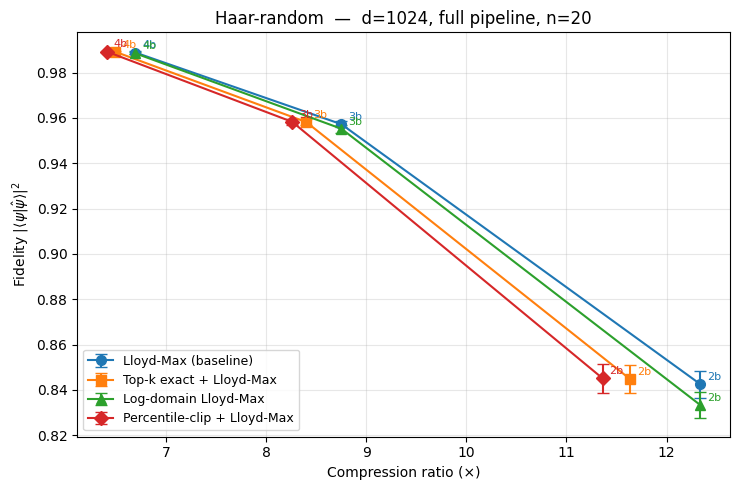

saved figures\haar_v2_quantizer_comparison.png


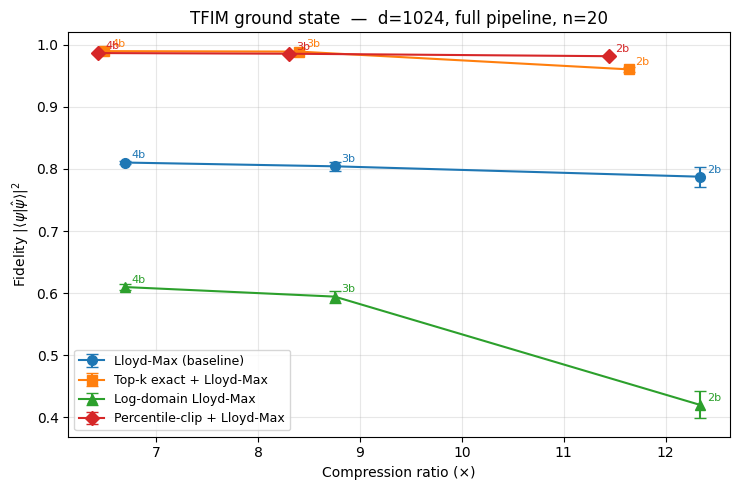

saved figures\tfim_v2_quantizer_comparison.png


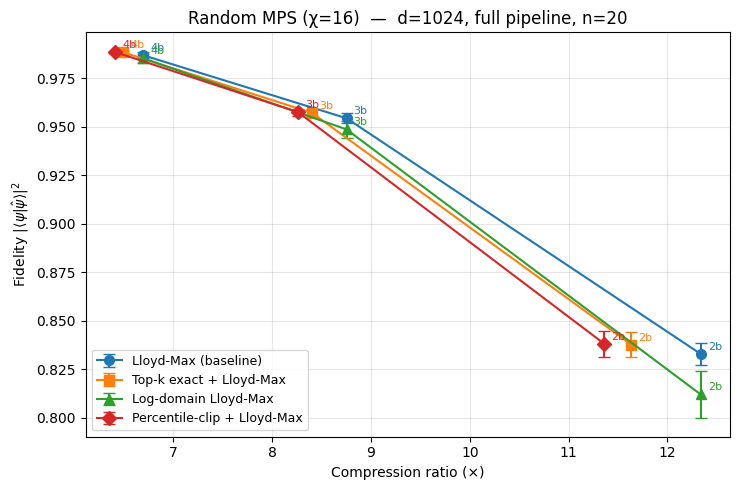

saved figures\mps_v2_quantizer_comparison.png


In [6]:
# One plot per state class. Four curves (one per quantizer), three points each
# (one per bit budget), error bars = std across 20 samples.
DEFAULT_BITS = 3
for state_name in STATE_NAMES:
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    for q in QUANTIZERS:
        sub = main[(main['state_class'] == state_name) &
                   (main['magnitude_quantizer'] == q)]
        g = (sub.groupby('bits_per_magnitude')
                 .agg(fid_mean=('fidelity', 'mean'),
                      fid_std=('fidelity', 'std'),
                      ratio=('compression_ratio', 'mean'))
                 .reset_index()
                 .sort_values('ratio'))
        ax.errorbar(g['ratio'], g['fid_mean'], yerr=g['fid_std'],
                    fmt=QUANTIZER_MARKERS[q] + '-',
                    color=QUANTIZER_COLORS[q],
                    capsize=4, lw=1.5, ms=7,
                    label=QUANTIZER_LABELS[q])
        # Annotate bit-budget at each point.
        for _, row in g.iterrows():
            ax.annotate(f'{int(row["bits_per_magnitude"])}b',
                        (row['ratio'], row['fid_mean']),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=8, color=QUANTIZER_COLORS[q])
    ax.set_xlabel('Compression ratio (×)')
    ax.set_ylabel('Fidelity $|\\langle\\psi|\\hat\\psi\\rangle|^2$')
    ax.set_title(f'{STATE_LABELS[state_name]}  —  d=1024, full pipeline, n=20')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=9)
    fig.tight_layout()
    out_path = FIG_DIR / f'{state_name}_v2_quantizer_comparison.png'
    fig.savefig(out_path, dpi=140)
    plt.show()
    print('saved', out_path)